pt2_forward shape as stored: (40, 3, 3, 3, 3, 8, 5, 7, 18)
pt2_forward shape after selection: (40, 2, 2, 3, 3, 8, 5, 7, 18)
smearings used: [(np.float64(16.0), np.float64(2.0)), (np.float64(40.0), np.float64(3.25))]  gammas used: ['G5', 'G45', 'G35']
basis 6x6: operator a = 3 * i_smear + i_gamma, i_smear and i_gamma counted within smear_use and gamma_use
forward C(t0) diagonal at pz 3: 0 positive, 6 negative, majority -
backward C(t0) diagonal at pz 3: 0 positive, 6 negative, majority -
pz 0: ground state E_eff at t = 5..8  forward 0.1446(0.0022) 0.1405(0.0020) 0.1414(0.0024) 0.1426(0.0017)  backward 0.1410(0.0026) 0.1440(0.0021) 0.1397(0.0021) 0.1413(0.0022)
pz 1: ground state E_eff at t = 5..8  forward 0.2438(0.0039) 0.2402(0.0031) 0.2376(0.0030) 0.2438(0.0032)  backward 0.2403(0.0045) 0.2416(0.0035) 0.2376(0.0025) 0.2437(0.0041)
pz 2: ground state E_eff at t = 5..8  forward 0.4217(0.0107) 0.4050(0.0135) 0.3959(0.0201) 0.3989(0.0261)  backward 0.4188(0.0121) 0.4224(0.0151) 0.4104(0.0

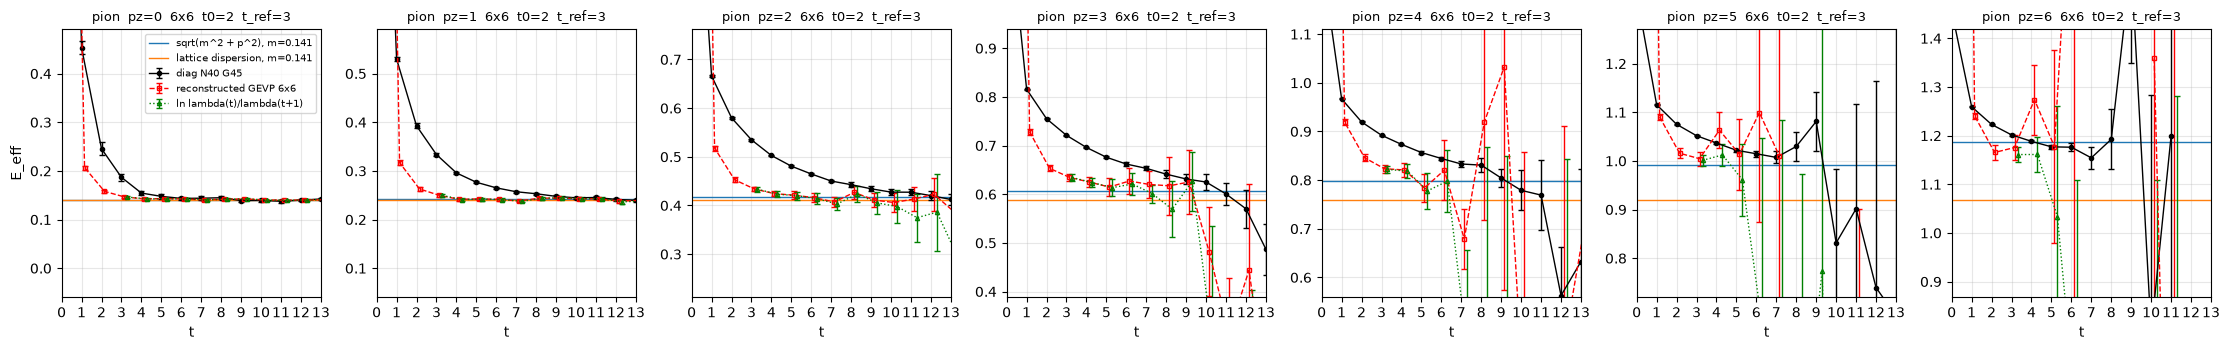

saved /Users/mcp3270/Desktop/GLUON_ANALYSIS_MANUAL/local_analysis/2pt_reconstructed_pion_smear01_gamma012_t02_tref3_64src_ncfg40.h5


In [22]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

def jk(data, jk_axis=0):
    n = data.shape[jk_axis]
    data = np.moveaxis(data, jk_axis, 0)
    mean = np.mean(data, axis=0)
    err = np.sqrt((n - 1.0) / n * np.sum((data - mean) ** 2, axis=0))
    return mean, err

def solve_gevp(C_matrix):
    eigen_val = np.full((n_pf, n_op, len(t_list)), np.nan)
    eigen_vec = np.full((n_pf, n_op, len(t_list), n_op), np.nan, "<c16")
    for ipf in range(n_pf):
        L = np.linalg.cholesky(C_matrix[:, :, ipf, t0])
        L_inv = np.linalg.inv(L)
        for it, t in enumerate(t_list):
            M = L_inv @ C_matrix[:, :, ipf, t] @ L_inv.conj().T
            w, u = np.linalg.eigh(M)
            v = L_inv.conj().T @ u
            order = np.argsort(w)[::-1]
            eigen_val[ipf, :, it] = w[order]
            eigen_vec[ipf, :, it] = v[:, order].T
    return eigen_val, eigen_vec

local = "/Users/mcp3270/Desktop/GLUON_ANALYSIS_MANUAL/local_analysis"
hadron = "pion"
smear_tag = "N16rho2.0_N40rho3.25_N96rho5.0"
pt2_path = f"{local}/2pt_{smear_tag}_GEVP_ez_momfrac0p6_{hadron}_tsrc_q5_fb_tsep18_64src_ncfg40.h5"

# which smearings and gammas to read (sink and source alike): smear 0 = N16, 1 = N40, 2 = N96;  gamma 0 = G5, 1 = G45, 2 = G35
smear_use = [0,1]
gamma_use = [0,1,2]
basis_tag = "smear" + "".join(str(s) for s in smear_use) + "_gamma" + "".join(str(g) for g in gamma_use)

with h5py.File(pt2_path, "r") as f:
    pt2_forward  = f["pt2_forward"][:]
    pt2_backward = f["pt2_backward"][:]
    pf_list  = f["pf_list"][:]
    q_list   = f["q_list"][:]
    cfg_list = f["cfg_list"][:]
    t_src_list = f["t_src_list"][:]
    smear_list = f["smear_list"][:]
    gamma_list = f.attrs["gamma_list"]
    dim_pt2 = f.attrs["dim_pt2"]

# (cfg,smear_sink,smear_source,gamma_sink,gamma_source,tsrc,q,psink,Lt)
#Phase-weighted average has been applied to 2pt on cluster, but for q=0 it's just a regular src average
print("pt2_forward shape as stored:", pt2_forward.shape)

# keep only the chosen smearings (axes 1 and 2) and gammas (axes 3 and 4), one axis at a time
pt2_forward  = pt2_forward[:, smear_use][:, :, smear_use][:, :, :, gamma_use][:, :, :, :, gamma_use]
pt2_backward = pt2_backward[:, smear_use][:, :, smear_use][:, :, :, gamma_use][:, :, :, :, gamma_use]
print("pt2_forward shape after selection:", pt2_forward.shape)
print("smearings used:", [tuple(smear_list[s]) for s in smear_use], " gammas used:", [gamma_list[g] for g in gamma_use])

C_half = {}
C_half["forward"]  = pt2_forward[:, :, :, :, :, :, 0].mean(axis=5)
C_half["backward"] = pt2_backward[:, :, :, :, :, :, 0].mean(axis=5)
n_cfg, n_smear, _, n_gamma, _, n_pf, tsep_max = C_half["forward"].shape
n_op = n_smear * n_gamma
print(f"basis {n_op}x{n_op}: operator a = {n_gamma} * i_smear + i_gamma, i_smear and i_gamma counted within smear_use and gamma_use")

t0 = 2
t_ref = 3

C = {}
for half in ["forward", "backward"]:
    C[half] = C_half[half].transpose(0, 1, 3, 2, 4, 5, 6).reshape(n_cfg, n_op, n_op, n_pf, tsep_max)
    C[half] = 0.5 * (C[half] + np.conj(np.swapaxes(C[half], 1, 2))) #average with C^dagger
    diagonal = np.diag(C[half].mean(axis=0)[:, :, 3, t0]).real
    n_positive = np.sum(diagonal > 0)
    n_negative = np.sum(diagonal < 0)
    print(half, "C(t0) diagonal at pz 3:", n_positive, "positive,", n_negative, "negative, majority", "+" if n_positive > n_negative else "-")

c_sign = -1
# the pion correlator is -1 times a positive-definite matrix in this convention; remove the sign (comment out to see the failures)
for half in ["forward", "backward"]:
    C[half] = c_sign * C[half]

# GEVP of one set of matrices C_matrix[a, b, pf, tsep]: eigenvalues lam[pf, n, t_list], eigenvectors vec[pf, n, t_list, op]
t_list = np.arange(t0 + 1, tsep_max)

# full average
eigen_val_central, eigen_vec_central = {}, {}
for half in ["forward", "backward"]:
    eigen_val_central[half], eigen_vec_central[half] = solve_gevp(C[half].mean(axis=0))

# jackknife: sample icfg is the average over all configs except icfg
eigen_val_jk, eigen_vec_jk = {}, {}
for half in ["forward", "backward"]:
    eigen_val_jk[half] = np.full((n_cfg, n_pf, n_op, len(t_list)), np.nan)
    eigen_vec_jk[half] = np.full((n_cfg, n_pf, n_op, len(t_list), n_op), np.nan, "<c16")
    for icfg in range(n_cfg):
        C_sample = (C[half].sum(axis=0) - C[half][icfg]) / (n_cfg - 1)
        eigen_val_jk[half][icfg], eigen_vec_jk[half][icfg] = solve_gevp(C_sample)

E_eff_central, E_eff_jk, E_eff_mean, E_eff_err = {}, {}, {}, {}
with np.errstate(invalid="ignore", divide="ignore"):
    for half in ["forward", "backward"]:
        E_eff_central[half] = np.log(eigen_val_central[half][..., :-1] / eigen_val_central[half][..., 1:])
        E_eff_jk[half] = np.log(eigen_val_jk[half][..., :-1] / eigen_val_jk[half][..., 1:])
        E_eff_mean[half], E_eff_err[half] = jk(E_eff_jk[half])

for ipf in range(n_pf):
    print(f"pz {pf_list[ipf][2]}: ground state E_eff at t = {t_list[2]}..{t_list[5]}  forward",
          " ".join(f"{E_eff_mean['forward'][ipf, 0, it]:.4f}({E_eff_err['forward'][ipf, 0, it]:.4f})" for it in range(2, 6)),
          " backward", " ".join(f"{E_eff_mean['backward'][ipf, 0, it]:.4f}({E_eff_err['backward'][ipf, 0, it]:.4f})" for it in range(2, 6)))

# ground-state vector of each half at t_ref: v0[half][pf, op]
it_ref = list(t_list).index(t_ref)
v0 = {}
for half in ["forward", "backward"]:
    v0[half] = eigen_vec_central[half][:, 0, it_ref, :]

# per-config, per-source-time, per-q matrices: pt2_matrix[half][cfg, a, b, tsrc, q, pf, tsep], no averaging
n_tsrc = pt2_forward.shape[5]
n_q = pt2_forward.shape[6]
pt2_matrix = {}
pt2_matrix["forward"]  = pt2_forward.transpose(0, 1, 3, 2, 4, 5, 6, 7, 8).reshape(n_cfg, n_op, n_op, n_tsrc, n_q, n_pf, tsep_max)
pt2_matrix["backward"] = pt2_backward.transpose(0, 1, 3, 2, 4, 5, 6, 7, 8).reshape(n_cfg, n_op, n_op, n_tsrc, n_q, n_pf, tsep_max)

# reconstructed 2pt: pt2_proj[half][cfg, tsrc, q, pf, tsep] = v0^dag C_data v0, same sign convention as C
pt2_proj = {}
for half in ["forward", "backward"]:
    pt2_proj[half] = c_sign * np.einsum("pa,cabtqpT,pb->ctqpT", np.conj(v0[half]), pt2_matrix[half], v0[half])

# reference diagonal: N40 G45 if both were read, otherwise the first operator of the basis
if 1 in smear_use and 1 in gamma_use:
    diag_index = smear_use.index(1) * n_gamma + gamma_use.index(1)
else:
    diag_index = 0
diag_label = f"diag N{int(smear_list[smear_use[diag_index // n_gamma]][0])} {gamma_list[gamma_use[diag_index % n_gamma]]}"
print("reference diagonal:", diag_label, "= operator", diag_index)

# effective mass of the reconstructed 2pt and of the reference diagonal: q = 0, source-time average, forward/backward average, jackknife
pt2_proj_avg = 0.5 * (pt2_proj["forward"][:, :, 0].mean(axis=1).real + pt2_proj["backward"][:, :, 0].mean(axis=1).real)
pt2_diag_avg = 0.5 * (C["forward"][:, diag_index, diag_index].real + C["backward"][:, diag_index, diag_index].real)
pt2_proj_jk = (pt2_proj_avg.sum(axis=0) - pt2_proj_avg) / (n_cfg - 1)
pt2_diag_jk = (pt2_diag_avg.sum(axis=0) - pt2_diag_avg) / (n_cfg - 1)
with np.errstate(invalid="ignore", divide="ignore"):
    meff_proj_mean, meff_proj_err = jk(np.log(pt2_proj_jk[..., :-1] / pt2_proj_jk[..., 1:]).real)
    meff_diag_mean, meff_diag_err = jk(np.log(pt2_diag_jk[..., :-1] / pt2_diag_jk[..., 1:]).real)
    E_lambda_jk = 0.5 * (E_eff_jk["forward"][:, :, 0, :] + E_eff_jk["backward"][:, :, 0, :])      # [cfg, pf, t]
    E_lambda_mean, E_lambda_err = jk(E_lambda_jk)

m_pi = 0.141
Ls = 32
plt.figure(figsize=(3.2 * n_pf, 3.6))
for ipf in range(n_pf):
    plt.subplot(1, n_pf, ipf + 1)
    E_disp = np.sqrt(m_pi ** 2 + (2 * np.pi * pf_list[ipf][2] / Ls) ** 2)
    plt.axhline(E_disp, color="C0", lw=1, label=f"sqrt(m^2 + p^2), m={m_pi}")
    p_lat = 2 * np.pi * pf_list[ipf][2] / Ls
    E_disp = 2 * np.arcsinh(np.sqrt(np.sinh(m_pi / 2) ** 2 + np.sin(p_lat / 2) ** 2))
    plt.axhline(E_disp, color="C1", lw=1, label=f"lattice dispersion, m={m_pi}")
    plt.errorbar(np.arange(tsep_max - 1), meff_diag_mean[ipf], meff_diag_err[ipf], fmt="ko-", ms=3, lw=1, capsize=2, label=diag_label)
    plt.errorbar(np.arange(tsep_max - 1) + 0.15, meff_proj_mean[ipf], meff_proj_err[ipf], fmt="rs--", ms=3, lw=1, capsize=2, mfc="none", label=f"reconstructed GEVP {n_op}x{n_op}")
    plt.errorbar(t_list[:-1] + 0.3, E_lambda_mean[ipf], E_lambda_err[ipf], fmt="g^:", ms=3, lw=1, capsize=2, mfc="none", label="ln lambda(t)/lambda(t+1)")
    plt.ylim(E_disp - 0.2, E_disp + 0.35)
    plt.xlim(0, 13)
    plt.xticks(np.arange(0, 14))
    plt.grid(alpha=0.3)
    plt.title(f"{hadron}  pz={pf_list[ipf][2]}  {n_op}x{n_op}  t0={t0}  t_ref={t_ref}", fontsize=9)
    plt.xlabel("t")
    if ipf == 0:
        plt.ylabel("E_eff")
        plt.legend(fontsize=7)
plt.tight_layout()
plt.savefig(f"{local}/meff_reconstructed_{hadron}_{basis_tag}_40cfg.png", dpi=150)
plt.show()

# save the reconstructed 2pt for the 3pt step
out_path = f"{local}/2pt_reconstructed_{hadron}_{basis_tag}_t0{t0}_tref{t_ref}_64src_ncfg40.h5"
with h5py.File(out_path, "w") as f:
    f.create_dataset("pt2_forward", data=pt2_proj["forward"])
    f.create_dataset("pt2_backward", data=pt2_proj["backward"])
    f.create_dataset("v0_forward", data=v0["forward"])
    f.create_dataset("v0_backward", data=v0["backward"])
    f.create_dataset("pf_list", data=pf_list)
    f.create_dataset("q_list", data=q_list)
    f.create_dataset("cfg_list", data=cfg_list)
    f.create_dataset("t_src_list", data=t_src_list)
    f.create_dataset("smear_use", data=np.array(smear_use))
    f.create_dataset("gamma_use", data=np.array(gamma_use))
    f.attrs["dim_pt2"] = "cfg, tsrc, q, pf, tsep"
    f.attrs["dim_v0"] = f"pf, op;  operator a = {n_gamma} * i_smear + i_gamma, i_smear over smear_use, i_gamma over gamma_use"
    f.attrs["t0"] = t0
    f.attrs["t_ref"] = t_ref
    f.attrs["c_sign"] = c_sign
    f.attrs["note"] = "v0 of each half applied to that half; q index 0 is the plain 2pt; for q != 0 the same v0(pf) is used at source and sink"
print("saved", out_path)

In [64]:
import h5py
import numpy as np
from opt_einsum import contract

def jackknife(x):
    n_cfg = x.shape[0]
    return (x.sum(axis=0) - x) / (n_cfg - 1)

F_or_B = "forward"
q_tag = "q000"
hyp_tag = "0-15"
pt2_choice = "gevp"            # "gevp": reconstructed 2pt;  "N40G45": single-operator diagonal from the same run, for comparison
pt2_tag = "smear2222222_t02_tref4"
local = "/Users/mcp3270/Desktop/GLUON_ANALYSIS_MANUAL/local_analysis"
FF_path = f"{local}/FF_streamd_hyp{hyp_tag}_{q_tag}_fb_tins18_64src_ncfg40.h5"
gevp_path = f"{local}/2pt_reconstructed_pion_{pt2_tag}_64src_ncfg40.h5"
raw_path = f"{local}/2pt_N16rho2.0_N40rho3.25_N96rho5.0_GEVP_ez_momfrac0p6_pion_tsrc_q5_fb_tsep18_64src_ncfg40.h5"
Ls = 32
WL_PHASE_SIGN = +1     # Fix the centering of Wilson line (trivial at q = 0)

FF_file = h5py.File(FF_path, "r")
FF_cfg = FF_file[f"FF_{F_or_B}"]                         # [cfg, tsrc, munu, rhosig, hyp, w, q, tau] = (40, 8, 6, 6, 16, 16, 1, 18)
q_list = FF_file["q_list"][:]                            # [[0, 0, 0]]
w_list = FF_file["w_list"][:]
hyp_list = FF_file["hyp_list"][:]
cfg_list = FF_file["cfg_list"][:]
print(FF_cfg.shape)

# 2pt: already phase-weighted and averaged over the spatial source positions on the cluster -> [cfg, tsrc, q, pf, tsep]
if pt2_choice == "gevp":
    pt2_file = h5py.File(gevp_path, "r")
    pt2_all = pt2_file[f"pt2_{F_or_B}"][:]                       # [cfg, tsrc, q, pf, tsep] = (40, 8, 5, 7, 18)
else:
    pt2_file = h5py.File(raw_path, "r")
    pt2_all = pt2_file[f"pt2_{F_or_B}"][:, 1, 1, 1, 1]           # smear_sink = smear_src = N40, gamma_sink = gamma_src = G45
q_list_pt2 = pt2_file["q_list"][:]
pf_list = pt2_file["pf_list"][:]
assert np.array_equal(pt2_file["cfg_list"][:], cfg_list)
assert np.array_equal(pt2_file["t_src_list"][:], FF_file["t_src_list"][:])
iq = [int(np.where((q_list_pt2 == q).all(axis=1))[0][0]) for q in q_list]   # position of each FF q in the 2pt q_list
pt2_src = pt2_all[:, :, iq].transpose(0, 1, 3, 4, 2)                          # [cfg, tsrc, pf, tsep, q] = (40, 8, 7, 18, 1)
n_cfg, n_tsrc = pt2_src.shape[:2]
print(pt2_src.shape)

#In my FF production code, Wilson line is not from -w/2 to w/2 so we need an extra phase factor to restore the convention (exactly)
wl_phase = np.exp(WL_PHASE_SIGN * 1j * np.pi / Ls * contract(w_list, ["w"], q_list[:, 2], ["q"], ["w", "q"]))    # [w, q] = (16, 1)
TXTX = contract(FF_cfg[:, :, 3, 3], ["cfg", "tsrc", "hyp", "w", "q", "tau"], wl_phase, ["w", "q"], ["cfg", "tsrc", "hyp", "w", "q", "tau"])
TYTY = contract(FF_cfg[:, :, 4, 4], ["cfg", "tsrc", "hyp", "w", "q", "tau"], wl_phase, ["w", "q"], ["cfg", "tsrc", "hyp", "w", "q", "tau"])
XYXY = contract(FF_cfg[:, :, 0, 0], ["cfg", "tsrc", "hyp", "w", "q", "tau"], wl_phase, ["w", "q"], ["cfg", "tsrc", "hyp", "w", "q", "tau"])
TXTXpTYTY = TXTX + TYTY
TXTXpTYTYm2XYXY = TXTXpTYTY - 2 * XYXY
TXTXpTYTYp2XYXY = TXTXpTYTY + 2 * XYXY
operators = [TXTX, TYTY, XYXY, TXTXpTYTY, TXTXpTYTYm2XYXY, TXTXpTYTYp2XYXY]
op_names = ["TXTX", "TYTY", "XYXY", "TXTXpTYTY", "TXTXpTYTYm2XYXY", "TXTXpTYTYp2XYXY"]

#Calculate the connected piece
pt2FF = []
for iop, op in enumerate(operators):
    print(iop)
    connected_term = contract(pt2_src, ["cfg", "tsrc", "pf", "tsep", "q"],
                              op,      ["cfg", "tsrc", "hyp", "w", "q", "tau"],
                                       ["cfg", "hyp", "w", "q", "tsep", "tau", "pf"])
    pt2FF.append(connected_term / n_tsrc)                # [cfg, hyp, w, q, tsep, tau, pf]

#Calculate the disconnected piece, method 1
pt2_avg = contract(pt2_src, ["cfg", "tsrc", "pf", "tsep", "q"], ["cfg", "pf", "tsep", "q"]) / n_tsrc
op_avg = []
for iop, op in enumerate(operators):
    op_avg.append(contract(op, ["cfg", "tsrc", "hyp", "w", "q", "tau"], ["cfg", "hyp", "w", "q", "tau"]) / n_tsrc)

pt2_jk = jackknife(pt2_avg)                              # [jk, pf, tsep, q]
op_jk = [jackknife(a) for a in op_avg]
pt2FF_jk = [jackknife(a) for a in pt2FF]
del pt2FF
pt3_vac_subtracted = []
for iop in range(len(operators)):
    vac_jk = contract(pt2_jk,     ["jk", "pf", "tsep", "q"],
                      op_jk[iop], ["jk", "hyp", "w", "q", "tau"],
                                  ["jk", "hyp", "w", "q", "tsep", "tau", "pf"])   # [jk, hyp, w, q, tsep, tau, pf] = (40, 16, 16, 1, 18, 18, 7)
    pt3_vac_subtracted.append(pt2FF_jk[iop] - vac_jk)

out_path = f"{local}/pt3_jk_method1_{pt2_choice}_{pt2_tag}_{F_or_B}_{q_tag}_hyp{hyp_tag}_64src_ncfg40.h5"
with h5py.File(out_path, "w") as f:
    for iop, name in enumerate(op_names):
        f.create_dataset(f"pt3_jk/{name}", data=pt3_vac_subtracted[iop])   # [jk, hyp, w, q, tsep, tau, pf]
    f.create_dataset("pt2_jk", data=pt2_jk)                                # [jk, pf, tsep, q]
    f.create_dataset("operator_names", data=np.array(op_names, dtype="S"))
    f.create_dataset("pf_list", data=pf_list)
    f.create_dataset("hyp_list", data=hyp_list)
    f.create_dataset("w_list", data=w_list)
    f.create_dataset("q_list", data=q_list)
    f.create_dataset("cfg_list", data=cfg_list)
    f.attrs["forward_or_backward"] = F_or_B
    f.attrs["pt2"] = f"{pt2_choice} {pt2_tag}" if pt2_choice == "gevp" else "N40 G45 diagonal of the 3-smear 3-gamma run"
    f.attrs["dim_pt3_jk"] = "jk, hyp, w, q, tsep, tau, pf"
    f.attrs["dim_pt2_jk"] = "jk, pf, tsep, q"
    f.attrs["smearing"] = FF_file.attrs["smearing"]
    f.attrs["vacuum_subtraction"] = "method 1: average over sources, jackknife over cfgs, multiply <C2><O>, subtract per replicate"
    f.attrs["wl_phase"] = f"exp({WL_PHASE_SIGN:+d} i pi q_z w / Ls), applied to the operator"
    f.attrs["jackknife"] = "delete-one, replicate k = mean over all cfgs except cfg_list[k]"
print("saved", out_path)

(40, 8, 6, 6, 16, 16, 1, 18)
(40, 8, 7, 18, 1)
0
1
2
3
4
5
saved /Users/mcp3270/Desktop/GLUON_ANALYSIS_MANUAL/local_analysis/pt3_jk_method1_gevp_smear2222222_t02_tref4_forward_q000_hyp0-15_64src_ncfg40.h5


In [68]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

def jk(data, jk_axis=0):
    n = data.shape[jk_axis]
    data = np.moveaxis(data, jk_axis, 0)
    mean = np.mean(data, axis=0)
    err = np.sqrt((n - 1.0) / n * np.sum((data - mean) ** 2, axis=0))
    return mean, err

method = 1
pt2_choice = "gevp"                    # "gevp" or "N40G45": must match the pt3_jk file names
pt2_tag = "smear2222222_t02_tref4"
local = "/Users/mcp3270/Desktop/GLUON_ANALYSIS_MANUAL/local_analysis"
q_tag = "q000"
hyp_tag = "0-15"
paths = {d: f"{local}/pt3_jk_method{method}_{pt2_choice}_{pt2_tag}_{d}_{q_tag}_hyp{hyp_tag}_64src_ncfg40.h5" for d in ("forward", "backward")}
operator = "TXTXpTYTYm2XYXY"
hyp_plot = 10
w_plot_list = [0, 2, 4, 6, 8]
tsep_plot_list = [4, 5, 6, 7, 8]
tsep_tag = f"tsep{tsep_plot_list[0]}-{tsep_plot_list[-1]}"
plot_dir = f"{local}/ratio_plots"
ratio_dir = f"{local}/ratio_data"
os.makedirs(plot_dir, exist_ok=True)
os.makedirs(ratio_dir, exist_ok=True)

# ---------- read forward and backward 3pt / 2pt jackknife lists ----------
pt3, pt2 = {}, {}
for d in ("forward", "backward"):
    with h5py.File(paths[d], "r") as f:
        pt3[d] = f[f"pt3_jk/{operator}"][:]      # [jk, hyp, w, q, tsep, tau, pf] = (40, 16, 16, 1, 18, 18, 7)
        pt2[d] = f["pt2_jk"][:, :, :, 0]         # [jk, pf, tsep] = (40, 7, 18)   q index 0 = (0,0,0)
        hyp_list = list(f["hyp_list"][:])
        w_list = list(f["w_list"][:])
        pf_list = f["pf_list"][:]
        q_list = f["q_list"][:]
        cfg_list = f["cfg_list"][:]
        vacuum_method = str(f.attrs["vacuum_subtraction"])
        pt2_note = str(f.attrs["pt2"])

pt3["fb"] = 0.5 * (pt3["forward"] + pt3["backward"])     # replicate by replicate: same cfg_list, same left-out cfg
pt2["fb"] = 0.5 * (pt2["forward"] + pt2["backward"])     # = folded 2pt

# ---------- ratio on every jackknife replicate, saved per direction ----------
ratio_mean, ratio_err = {}, {}
for d in ("forward", "backward", "fb"):
    c2 = pt2[d].transpose(0, 2, 1)                                      # [jk, tsep, pf]
    ratio_jk = pt3[d].real / c2[:, None, None, None, :, None, :].real   # [jk, hyp, w, q, tsep, tau, pf]
    ratio_mean[d], ratio_err[d] = jk(ratio_jk)                          # each [hyp, w, q, tsep, tau, pf]
    out = f"{ratio_dir}/ratio_method{method}_{pt2_choice}_{pt2_tag}_{d}_{operator}_{q_tag}_hyp{hyp_tag}_64src_ncfg40.h5"
    with h5py.File(out, "w") as f:
        f.create_dataset("ratio_jk", data=ratio_jk)                     # [jk, hyp, w, q, tsep, tau, pf]   tau > tsep is not a ratio
        f.create_dataset("ratio_mean", data=ratio_mean[d])              # [hyp, w, q, tsep, tau, pf]
        f.create_dataset("ratio_err", data=ratio_err[d])                # [hyp, w, q, tsep, tau, pf]
        f.create_dataset("hyp_list", data=np.array(hyp_list, dtype=np.int64))
        f.create_dataset("w_list", data=np.array(w_list, dtype=np.int64))
        f.create_dataset("pf_list", data=pf_list)
        f.create_dataset("q_list", data=q_list)
        f.create_dataset("cfg_list", data=cfg_list)
        f.attrs["dim_ratio_jk"] = "jk, hyp, w, q, tsep, tau, pf"
        f.attrs["ratio_definition"] = "R = Re C3(tsep,tau) / Re C2(pf,tsep)"
        f.attrs["operator"] = operator
        f.attrs["pt2"] = pt2_note
        f.attrs["vacuum_method"] = method
        f.attrs["vacuum_subtraction"] = vacuum_method
        f.attrs["direction"] = d + ("" if d != "fb" else ": 0.5 * (forward + backward) of the 3pt and 2pt jackknife lists, then the ratio")
        f.attrs["pt3_source"] = paths.get(d, f"{paths['forward']} + {paths['backward']}")
    print(f"saved {out}")

# ---------- plots: one figure per pz, one panel per w: forward vs forward+backward ----------
style = {"forward": dict(marker="o", ls="none", ms=4),
         "fb":      dict(marker="o", mfc="none", ls="none", ms=5)}
offset = {"forward": -0.08, "fb": +0.08}
ihyp = hyp_list.index(hyp_plot)
for ipf, pf in enumerate(pf_list):
    plt.figure(figsize=(4.2 * len(w_plot_list), 4.5))
    for icol, w in enumerate(w_plot_list):
        iw = w_list.index(w)
        plt.subplot(1, len(w_plot_list), icol + 1)
        for itsep, tsep in enumerate(tsep_plot_list):
            tau = np.arange(0, tsep + 1)
            x = tau - tsep / 2
            for d in ("forward", "fb"):
                plt.errorbar(x + offset[d], ratio_mean[d][ihyp, iw, 0, tsep, tau, ipf],
                             yerr=ratio_err[d][ihyp, iw, 0, tsep, tau, ipf],
                             capsize=2, color=f"C{itsep}",
                             label=f"tsep={tsep}" if d == "forward" else None, **style[d])
        plt.title(f"pz={pf[2]}  w={w}   filled: forward,  hollow: forward+backward", fontsize=9)
        plt.xlabel("tau - tsep/2")
        plt.autoscale(enable=False, axis="y")
        plt.ylim(-0.5, 0.1)
        if icol == 0:
            plt.ylabel("R = C3 / C2")
        if icol == len(w_plot_list) - 1:
            plt.legend(fontsize=7)
    plt.suptitle(f"{operator}   2pt: {pt2_choice} {pt2_tag}   method {method}   hyp{hyp_plot}   {q_tag}   64src x 40cfg", fontsize=12)
    plt.tight_layout()
    out = f"{plot_dir}/ratio_method{method}_{pt2_choice}_{pt2_tag}_fwd_vs_fb_{operator}_hyp{hyp_plot}_pz{pf[2]}_{tsep_tag}.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"saved {out}")

saved /Users/mcp3270/Desktop/GLUON_ANALYSIS_MANUAL/local_analysis/ratio_data/ratio_method1_gevp_smear2222222_t02_tref4_forward_TXTXpTYTYm2XYXY_q000_hyp0-15_64src_ncfg40.h5
saved /Users/mcp3270/Desktop/GLUON_ANALYSIS_MANUAL/local_analysis/ratio_data/ratio_method1_gevp_smear2222222_t02_tref4_backward_TXTXpTYTYm2XYXY_q000_hyp0-15_64src_ncfg40.h5
saved /Users/mcp3270/Desktop/GLUON_ANALYSIS_MANUAL/local_analysis/ratio_data/ratio_method1_gevp_smear2222222_t02_tref4_fb_TXTXpTYTYm2XYXY_q000_hyp0-15_64src_ncfg40.h5
saved /Users/mcp3270/Desktop/GLUON_ANALYSIS_MANUAL/local_analysis/ratio_plots/ratio_method1_gevp_smear2222222_t02_tref4_fwd_vs_fb_TXTXpTYTYm2XYXY_hyp10_pz0_tsep4-8.png
saved /Users/mcp3270/Desktop/GLUON_ANALYSIS_MANUAL/local_analysis/ratio_plots/ratio_method1_gevp_smear2222222_t02_tref4_fwd_vs_fb_TXTXpTYTYm2XYXY_hyp10_pz1_tsep4-8.png
saved /Users/mcp3270/Desktop/GLUON_ANALYSIS_MANUAL/local_analysis/ratio_plots/ratio_method1_gevp_smear2222222_t02_tref4_fwd_vs_fb_TXTXpTYTYm2XYXY_hyp10_